# Insider Threat Behavioral Intelligence System

## Model Evaluation (Isolation Forest vs Local Outlier Factor)

This notebook evaluates anomaly detection performance using two unsupervised machine learning algorithms:

- Isolation Forest
- Local Outlier Factor (LOF)

The notebook compares predictions, anomaly counts, and model behavior on the engineered behavioral feature dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

DATA_PATH = PROJECT_ROOT / "datasets" / "processed" / "final_features.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(265, 11)


,user,device_connections,emails_sent,files_accessed,websites_visited,logon_count,O,C,E,A,N
0,LRR0148,1569,0,907,57200,1378,21,19,14,14,29
1,HAH0760,1342,150,1900,10034,957,34,17,22,37,30
2,BIS0247,232,413,418,31140,1056,36,19,18,39,37
3,MAR0955,42,0,69,2963,604,36,44,23,44,25
4,OCS0865,1310,725,873,56052,1005,29,24,43,35,32


In [3]:
users = df["user"]

X = df.drop(columns=["user"])

print(X.shape)
X.head()

(265, 10)


,device_connections,emails_sent,files_accessed,websites_visited,logon_count,O,C,E,A,N
0,1569,0,907,57200,1378,21,19,14,14,29
1,1342,150,1900,10034,957,34,17,22,37,30
2,232,413,418,31140,1056,36,19,18,39,37
3,42,0,69,2963,604,36,44,23,44,25
4,1310,725,873,56052,1005,29,24,43,35,32


In [4]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_predictions = iso.fit_predict(X)

df["IsolationForest"] = iso_predictions

print(df["IsolationForest"].value_counts())

IsolationForest
 1    251
-1     14
Name: count, dtype: int64


In [5]:
lof = LocalOutlierFactor(
    contamination=0.05
)

lof_predictions = lof.fit_predict(X)

df["LOF"] = lof_predictions

print(df["LOF"].value_counts())

LOF
 1    251
-1     14
Name: count, dtype: int64


In [7]:
comparison = pd.crosstab(
    df["IsolationForest"],
    df["LOF"]
)

print(comparison)

LOF              -1    1
IsolationForest         
-1                4   10
 1               10  241


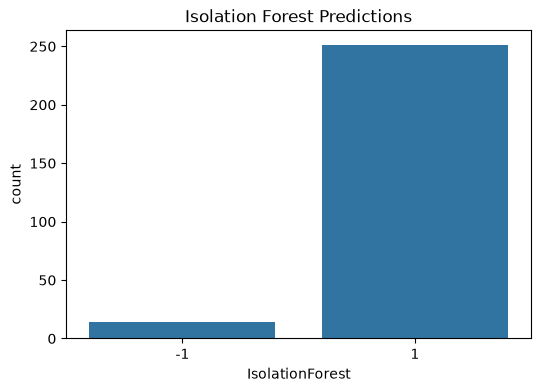

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="IsolationForest",
    data=df
)

plt.title("Isolation Forest Predictions")
plt.show()

In [10]:
print("Isolation Forest")
print(df["IsolationForest"].value_counts())

print("\nLOF")
print(df["LOF"].value_counts())

Isolation Forest
IsolationForest
 1    251
-1     14
Name: count, dtype: int64

LOF
LOF
 1    251
-1     14
Name: count, dtype: int64


In [11]:
OUTPUT_PATH = PROJECT_ROOT / "datasets" / "processed"

df.to_csv(
    OUTPUT_PATH / "evaluation_results.csv",
    index=False
)

print("Evaluation results saved!")

Evaluation results saved!
